# Dino Slayer — Notebook 2: Coverage Model Training

**Stage 4 of the geospatial pipeline: features and indicators → predictions.**

Notebook 01 produced a settlement-level feature stack. This notebook trains a **supervised
regression** model on it, following the task definitions from **Module 3, Session 2.2
(Fundamentals of Machine Learning)**: predicting a continuous value — "how much?" — rather
than a category or a grouping.

---

### What is being predicted, and why

**Target (`y`): `dl_mbps`** — median observed mobile download speed.

850 settlements have trustworthy measurements. **216 have none at all.** For those, the
dashboard can only say "not scored, measurement needed". A model that estimates their likely
speed, *with its uncertainty attached*, turns the largest hole in the project into something a
planner can act on.

Framed honestly, this is **regression imputation**: filling a missing value with a supervised
model instead of a mean. What makes it defensible is that it is validated on held-out
geography rather than assumed to work.

### What is deliberately NOT predicted

**DIPI.** DIPI is a weighted sum of four pillars we computed ourselves. A model predicting it
from those same columns would score near-perfect R² by re-deriving arithmetic, and would have
learned nothing. This is the first thing a GeoAI judge tests for.

---

### Beyond the bootcamp

The bootcamp material covers supervised regression, model families and MAE/RMSE. It does not
cover cross-validation, spatial grouping, or SHAP. Those are added here because the data
demands them, and they are flagged as our own additions rather than taught method:

- **Spatial cross-validation (GroupKFold by district)** — 29% of settlements share an exact
  speed value with a neighbour because they fall in the same Ookla tile. A random split puts
  twins on both sides and the score becomes meaningless.
- **SHAP** — per-settlement explanation, so every estimate can state its own reasons.
- **Fold-ensemble disagreement** — uncertainty from the spread across five fold models.

---

### Before running

`training_table.csv` must be in `MyDrive/Dataset/` (from the team's
`export_training_table.py`). Its hash is verified below.

`ocid_sabah.parquet` comes from notebook 01.

In [ ]:
# ══════════════════════════════════════════════════════════════════════
# SETUP
# ══════════════════════════════════════════════════════════════════════
!pip install -q xgboost shap

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd, numpy as np, hashlib, json, os, datetime
import geopandas as gpd
from tqdm.notebook import tqdm

D    = "/content/drive/MyDrive/Dataset/"
SEED = 42                     # every random operation is seeded — reproducibility rule
np.random.seed(SEED)
os.makedirs(D + "outputs", exist_ok=True)

print("files in Dataset/:")
for f in sorted(os.listdir(D)):
    print("  ", f)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
files in Dataset/:
   502.csv.gz
   dipi.geojson
   facilities_sabah.parquet
   gadm41_MYS_1.json
   gadm41_MYS_2.json
   ocid_sabah.parquet
   outputs
   sabah_districts.geojson
   settlements_sabah.parquet
   settlements_sabah_dipi_v1.parquet
   settlements_sabah_features_v1.parquet
   settlements_sabah_full.parquet
   settlements_sabah_full_BACKUP.parquet
   settlements_sabah_pop.parquet
   tiles_sabah_2025q1.parquet
   tiles_sabah_2025q2.parquet
   tiles_sabah_2025q3.parquet
   tiles_sabah_2025q4.parquet
   tower_isolated.csv
   tower_pairs.csv
   training_table.csv


---
## 1. Load and verify the frozen training table

The modelling input is **version-locked by hash**. If someone regenerates
`training_table.csv`, every number in this notebook changes, and comparing a new run against
old results would be meaningless. The assertion below makes that impossible to do by accident.

In [ ]:
# ══════════════════════════════════════════════════════════════════════
# Verify the exact modelling input. A different hash = a different file =
# results that cannot be compared with anything reported previously.
# ══════════════════════════════════════════════════════════════════════
TT       = D + "training_table.csv"
EXPECTED = "fd0d29125cc21286e11a1ea74cdc167bc961fc8f15e147634618fb75a0d01845"

assert os.path.exists(TT), "training_table.csv missing — generated by export_training_table.py"

FULL_HASH = hashlib.sha256(open(TT, "rb").read()).hexdigest()
df = pd.read_csv(TT)

print(f"sha256   : {FULL_HASH}")
print(f"expected : {EXPECTED}")
print(f"shape    : {df.shape}")
assert FULL_HASH == EXPECTED, "WRONG FILE VERSION"
assert df.shape == (1448, 20)
print("\nverified ✓ frozen modelling input")

sha256   : fd0d29125cc21286e11a1ea74cdc167bc961fc8f15e147634618fb75a0d01845
expected : fd0d29125cc21286e11a1ea74cdc167bc961fc8f15e147634618fb75a0d01845
shape    : (1448, 20)

verified ✓ frozen modelling input


In [ ]:
# ══════════════════════════════════════════════════════════════════════
# THE GATE — nothing is trained until this has been read and approved.
# ══════════════════════════════════════════════════════════════════════
print("COLUMNS")
for c in df.columns:
    print(f"  {c:32s} {str(df[c].dtype):8s} missing={int(df[c].isna().sum())}")

print("\nSPLITS")
print(df.split.value_counts().to_string())

print("\nTARGET dl_mbps")
print(df.dl_mbps.describe().round(2).to_string())
print("  → heavily right-skewed (mean >> median). The model trains on log1p(y).")

print(f"\nGROUPS: {df.district.nunique()} districts, {df.division.nunique()} divisions")
dc = df.district.value_counts()
print(f"  rows per district: min={dc.min()}, max={dc.max()}")

# The evidence for spatial CV, recomputed rather than asserted
dup    = df.dl_mbps.dropna()
shared = dup.duplicated(keep=False).sum()
print(f"\nTILE-SHARING: {shared}/{len(dup)} ({shared/len(dup)*100:.0f}%) of settlements with a")
print("  speed share an EXACT value with another — same Ookla tile, same aggregate.")
print("  Under a random split those twins land on opposite sides and the model gets")
print("  credit for predicting a number it was shown. Grouped CV is mandatory.")

COLUMNS
  settlement_id                    object   missing=0
  name                             object   missing=38
  lon                              float64  missing=0
  lat                              float64  missing=0
  district                         object   missing=0
  division                         object   missing=0
  pop_2km                          int64    missing=0
  n_schools_3km                    int64    missing=0
  n_clinics_3km                    int64    missing=0
  rwi                              float64  missing=96
  elevation_m                      float64  missing=0
  seasonal_water_px                int64    missing=0
  flood_prone                      bool     missing=0
  place                            object   missing=0
  backhaul_km                      float64  missing=0
  elev_drop_m                      float64  missing=59
  elev_pct_district                float64  missing=2
  dl_mbps                          float64  missing=216
  split        

In [ ]:
# ══════════════════════════════════════════════════════════════════════
# DATA QUALITY AUDIT — checked before modelling, not after a bad result.
# ══════════════════════════════════════════════════════════════════════
print("IDENTITY")
print(f"  duplicate settlement_id : {df.settlement_id.duplicated().sum()}  (must be 0)")
print(f"  duplicate (lon,lat)     : {df.duplicated(['lon','lat']).sum()}  (must be 0)")

print("\nCOORDINATES (Sabah ≈ 115.1-119.3 E, 4.0-7.4 N)")
print(f"  lon {df.lon.min():.3f} – {df.lon.max():.3f}   lat {df.lat.min():.3f} – {df.lat.max():.3f}")
bad = ((df.lon < 115) | (df.lon > 119.5) | (df.lat < 3.9) | (df.lat > 7.5)).sum()
print(f"  impossible coords       : {bad}  (must be 0)")

print("\nTARGET, training rows only")
tr_df  = df[df.split == "train"]
q1, q3 = tr_df.dl_mbps.quantile([.25, .75]); iqr = q3 - q1
print(f"  n={len(tr_df)}  min={tr_df.dl_mbps.min():.2f}  median={tr_df.dl_mbps.median():.2f}  max={tr_df.dl_mbps.max():.2f} Mbps")
print(f"  high outliers (>Q3+1.5·IQR): {(tr_df.dl_mbps > q3+1.5*iqr).sum()}  — retained, they are real")

print("\nMEASURED LABELS BY DISTRICT — these are the cross-validation groups")
vc = tr_df.district.value_counts()
print(vc.to_string())
print(f"\n  districts with <10 training rows: {(vc < 10).sum()}")
print("  → per-district error statistics for those are noise. Always report the count.")

print("\nMISSING VALUES")
print(df.isna().sum()[lambda s: s > 0].to_string())
print("  rwi 96          = 'no wealth data', NOT poor")
print("  elev_drop_m 59  = the anchor towns themselves, where a drop is meaningless")
print("  dl_mbps 216     = the settlements we predict — NEVER imputed")
print("  name 38         = unnamed OSM places — join on settlement_id only")

IDENTITY
  duplicate settlement_id : 0  (must be 0)
  duplicate (lon,lat)     : 0  (must be 0)

COORDINATES (Sabah ≈ 115.1-119.3 E, 4.0-7.4 N)
  lon 115.358 – 119.215   lat 4.228 – 7.346
  impossible coords       : 0  (must be 0)

TARGET, training rows only
  n=850  min=3.38  median=47.21  max=328.64 Mbps
  high outliers (>Q3+1.5·IQR): 49  — retained, they are real

MEASURED LABELS BY DISTRICT — these are the cross-validation groups
district
Ranau           181
Keningau        153
KotaBelud        70
Tenom            53
Tuaran           51
Pitas            39
KotaKinabalu     34
Sandakan         33
Tambunan         32
Kunak            29
Papar            24
Beaufort         23
Beluran          22
KotaMarudu       20
Nabawan          15
Tawau            12
KualaPenyu       10
Kinabatangan     10
Kudat             9
Penampang         8
Sipitang          8
LahadDatu         6
Tongod            3
Semporna          3
Putatan           2

  districts with <10 training rows: 7
  → per-distric

### Split provenance — documented, not assumed

A supplied `split` column is not automatically a valid validation design. Before using it,
two things must be established: how it was made, and whether it is spatial.

Both are answered below from the data itself.

In [ ]:
# ══════════════════════════════════════════════════════════════════════
# SPLIT PROVENANCE
# ══════════════════════════════════════════════════════════════════════
print("split ↔ evidence_tier — a perfectly diagonal table means split is")
print("just a renaming of the evidence tier:")
print(pd.crosstab(df.split, df.evidence_tier_REFERENCE_ONLY).to_string())

sp = df.groupby("district").split.nunique()
print(f"\ndistricts spanning more than one split: {(sp>1).sum()} of {df.district.nunique()}")
print("→ split is EVIDENCE-based, NOT spatial. A separate spatial fold_id is required.")

print("""
PROVENANCE (from the P2 join in notebook 01, not guessed):
  evidence_tier = 'measured'     if n_tests >= 20 AND n_tiles >= 3
                = 'insufficient' if n_tests < 5
                = 'low_evidence' otherwise
  n_tests and n_tiles describe HOW the target was measured.
  → split and evidence_tier are therefore TARGET-DERIVED and are banned as
    predictors. Both are in the BANNED list below.

ROW-USE DECISION (explicit — the 1,232 rows with a target are NOT pooled):
  train    850  measured,     median 148 tests  -> FIT the model
  validate 264  low_evidence, median  11 tests  -> EVALUATION ONLY, labels too noisy to fit
  check    118  insufficient but has a value    -> DIAGNOSTIC ONLY
  predict  216  no measurement at all           -> INFERENCE. Target never imputed.
""")

split ↔ evidence_tier — a perfectly diagonal table means split is
just a renaming of the evidence tier:
evidence_tier_REFERENCE_ONLY  insufficient  low_evidence  measured
split                                                             
check                                  118             0         0
predict                                216             0         0
train                                    0             0       850
validate                                 0           264         0

districts spanning more than one split: 23 of 25
→ split is EVIDENCE-based, NOT spatial. A separate spatial fold_id is required.

PROVENANCE (from the P2 join in notebook 01, not guessed):
  evidence_tier = 'measured'     if n_tests >= 20 AND n_tiles >= 3
                = 'insufficient' if n_tests < 5
                = 'low_evidence' otherwise
  n_tests and n_tiles describe HOW the target was measured.
  → split and evidence_tier are therefore TARGET-DERIVED and are banned as
    predict

---
## 2. Feature sets and leakage control

**Leakage** is the failure mode that makes a model look excellent and be worthless: a feature
that encodes the answer. Each banned column below leaks in a specific way.

| Banned | How it leaks |
|---|---|
| `dl_mbps` | it is the target |
| `split`, `evidence_tier_REFERENCE_ONLY` | derived from `n_tests` — describes how the target was measured |
| `n_tests`, `n_tiles` | same |
| `ul_mbps`, `latency_ms` | measured from the same Ookla tile as the target |
| `p_connectivity`, `dipi`, `rank` | contain the target, rescaled |
| `stakes_score`, `gap_rank` | exist only for prediction rows, never for training rows |
| `lon`, `lat` | location memorisation — used for grouping and mapping, never as predictors |
| `district` | it **is** the cross-validation group; a held-out district is a category never seen in training |

### The ablation design

Four variants, all sharing identical rows, folds, preprocessing, parameters and seed. Only
the feature list changes, so any difference in score is attributable to the features and
nothing else.

| Model | Features |
|---|---|
| **A** | 9 base features, no terrain |
| **B1** | A + `elevation_m` only |
| **B2** | B1 + `elev_drop_m` + `elev_pct_district` |
| **A + division** | A + regional label (tested as a remedy for district bias) |
| **C** | A + OpenCelliD telecom supply |

In [ ]:
# ══════════════════════════════════════════════════════════════════════
# FEATURE SETS + LEAKAGE GUARD
# The asserts below are cheap insurance: if a banned column is ever added
# to a feature list by accident, the notebook stops instead of producing
# an impressive and meaningless score.
# ══════════════════════════════════════════════════════════════════════
FEATURES_A = [
    "pop_2km",            # people within 2 km  (stakes)
    "n_schools_3km",      # mapped schools within 3 km
    "n_clinics_3km",      # mapped clinics/hospitals/doctors within 3 km
    "rwi",                # relative wealth; NaN kept, never imputed
    "seasonal_water_px",  # seasonal water adjacency (context)
    "flood_prone",        # boolean form of the above
    "place",              # hamlet / village / town / city
    "backhaul_km",        # distance to nearest town = REMOTENESS, not terrain
    "rwi_missing",        # missingness may itself signal remoteness
]
FEATURES_B1 = FEATURES_A  + ["elevation_m"]
FEATURES_B2 = FEATURES_B1 + ["elev_drop_m", "elev_pct_district", "elev_drop_missing"]

TERRAIN = ["elevation_m", "elev_drop_m", "elev_pct_district"]
BANNED  = ["dl_mbps", "split", "evidence_tier_REFERENCE_ONLY", "settlement_id", "name",
           "p_connectivity", "dipi", "rank", "ul_mbps", "latency_ms",
           "n_tests", "n_tiles", "evidence_tier", "stakes_score", "gap_rank",
           "lon", "lat", "district", "division"]

assert not [c for c in FEATURES_A if c in TERRAIN], "Model A must contain NO terrain"
for nm, fs in [("A", FEATURES_A), ("B1", FEATURES_B1), ("B2", FEATURES_B2)]:
    assert not [c for c in fs if c in BANNED], f"LEAKAGE in {nm}"
    print(f"Model {nm:2s}: {len(fs):2d} features, 0 leaks ✓")

print(f"\nB1 − A  = {sorted(set(FEATURES_B1) - set(FEATURES_A))}")
print(f"B2 − B1 = {sorted(set(FEATURES_B2) - set(FEATURES_B1))}")

Model A :  9 features, 0 leaks ✓
Model B1: 10 features, 0 leaks ✓
Model B2: 13 features, 0 leaks ✓

B1 − A  = ['elevation_m']
B2 − B1 = ['elev_drop_m', 'elev_drop_missing', 'elev_pct_district']


In [ ]:
# ══════════════════════════════════════════════════════════════════════
# BUILD THE FRAME + LOCK THE RUN CONFIGURATION
#
# Preprocessing note: NOTHING is fitted on the data. No imputer, no scaler,
# no encoder learned from values. XGBoost handles NaN natively and learns a
# default direction, and the categorical levels are a fixed known domain.
# Because nothing is fitted, nothing can leak from a validation fold into
# training — the usual reason preprocessing must sit inside a pipeline.
#
# Why rwi is NOT imputed: RWI is negative for poorer areas, so filling with
# 0 would mean "average wealth" and would be inventing data for the 96
# settlements the source does not cover.
# ══════════════════════════════════════════════════════════════════════
import xgboost, sklearn

d = df.copy()
d["flood_prone"]       = d.flood_prone.astype(int)
d["rwi_missing"]       = d.rwi.isna().astype(int)             # row-wise → fold-safe
d["elev_drop_missing"] = d.elev_drop_m.isna().astype(int)
d["place"] = pd.Categorical(d.place, categories=["hamlet","village","town","city"])

XGB_PARAMS = dict(n_estimators=400, learning_rate=0.05, max_depth=5,
                  subsample=0.8, colsample_bytree=0.8,
                  random_state=SEED, enable_categorical=True, tree_method="hist")

CONFIG = {
  "table_sha256": FULL_HASH, "shape": list(df.shape),
  "target": "dl_mbps", "units": "Mbps", "transform": "log1p fit / expm1 report",
  "target_period": "Ookla mobile tiles 2025 Q1-Q4, median avg_d_kbps/1000 within a 2 km buffer",
  "train_rule": "split=='train' (evidence_tier=='measured': n_tests>=20 & n_tiles>=3), n=850",
  "row_use": {"train":"fit", "validate":"evaluation only",
              "check":"diagnostic only", "predict":"inference; target never imputed"},
  "split_provenance": "derived from evidence_tier (n_tests/n_tiles) => target-derived => banned as predictor; NOT spatial",
  "preprocessing": "flood_prone->int; place->fixed categorical; row-wise missingness flags; "
                   "NO imputation (XGBoost native NaN) => nothing fitted, nothing leaks",
  "features_A": FEATURES_A, "features_B1": FEATURES_B1, "features_B2": FEATURES_B2,
  "seed": SEED, "params": XGB_PARAMS,
  "cv": "GroupKFold(5) groups=district; naive KFold(5) reported alongside as the leakage exhibit",
  "uncertainty": "fold-ensemble disagreement (mean, std across 5 fold models) — NOT a calibrated interval",
  "versions": {"xgboost": xgboost.__version__, "sklearn": sklearn.__version__,
               "pandas": pd.__version__, "numpy": np.__version__},
  "run_date": datetime.date.today().isoformat(),
}
json.dump(CONFIG, open(D + "outputs/run_config.json", "w"), indent=2, default=str)
print("locked → outputs/run_config.json ✓")
print(f"rwi_missing={d.rwi_missing.sum()}   elev_drop_missing={d.elev_drop_missing.sum()}")

locked → outputs/run_config.json ✓
rwi_missing=96   elev_drop_missing=59


---
## 3. Spatial cross-validation — freeze the folds

**This is the methodological core of the project.**

Standard cross-validation shuffles rows at random. On spatial data that leaks: neighbouring
settlements share Ookla tiles, so a random split trains on a value and then tests on its twin.

`GroupKFold` grouped by **district** holds out whole districts, so the model must predict
geography it has never seen. That is the question a planner actually has — *what about the
places we have not measured?* — and it is a much harder test.

The folds are **frozen and exported before any model runs**. Every variant uses these exact
ids, which is what makes the comparison valid.

In [ ]:
# ══════════════════════════════════════════════════════════════════════
# FREEZE THE FOLDS. Nothing may be trained before this file exists.
# ══════════════════════════════════════════════════════════════════════
from sklearn.model_selection import GroupKFold

train_mask = d.split == "train"
d["fold_id"] = -1                                  # -1 = not a training row
idx = d.index[train_mask]
for k, (_, te) in enumerate(GroupKFold(n_splits=5).split(idx, groups=d.loc[idx, "district"])):
    d.loc[idx[te], "fold_id"] = k

d[["settlement_id","district","split","fold_id"]].to_csv(D + "outputs/fold_assignment.csv", index=False)

for k in range(5):
    f = d[d.fold_id == k]
    print(f"fold {k}: {len(f):3d} rows | {sorted(f.district.unique())}")

assert (d.loc[train_mask, "fold_id"] >= 0).all()
assert d[d.fold_id >= 0].groupby("district").fold_id.nunique().max() == 1, "a district spans two folds"
print("\nsaved ✓ outputs/fold_assignment.csv — no district spans two folds")
print("\nNote: the largest district cannot be split, so one fold may hold a single")
print("district. That makes it a harder, more concentrated test — worth stating.")

fold 0: 181 rows | ['Ranau']
fold 1: 169 rows | ['Keningau', 'Kinabatangan', 'LahadDatu']
fold 2: 167 rows | ['KotaBelud', 'KotaMarudu', 'KualaPenyu', 'Papar', 'Penampang', 'Putatan', 'Sandakan']
fold 3: 166 rows | ['Beaufort', 'KotaKinabalu', 'Kudat', 'Tambunan', 'Tawau', 'Tenom', 'Tongod']
fold 4: 167 rows | ['Beluran', 'Kunak', 'Nabawan', 'Pitas', 'Semporna', 'Sipitang', 'Tuaran']

saved ✓ outputs/fold_assignment.csv — no district spans two folds

Note: the largest district cannot be split, so one fold may hold a single
district. That makes it a harder, more concentrated test — worth stating.


In [ ]:
# ══════════════════════════════════════════════════════════════════════
# BASELINES — "beat a baseline or say so".
# A model that cannot beat predicting the median is not a model.
#
# Both baselines are computed WITHIN each fold's training half, so they are
# measured the same way as the model. Note that under district-grouped CV a
# district-median baseline collapses into the global median, because the
# held-out district never appears in training. That is honest, not a bug.
# ══════════════════════════════════════════════════════════════════════
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def metrics(y_true, y_pred):
    """MAE is directly interpretable in Mbps; RMSE punishes large misses; R2 is scale-free."""
    return {"MAE":  mean_absolute_error(y_true, y_pred),
            "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
            "R2":   r2_score(y_true, y_pred)}

tr = d[d.split == "train"].copy()
y  = tr.dl_mbps.values

pred_gm = np.empty(len(tr))
for k in range(5):
    te = (tr.fold_id == k).values
    pred_gm[te] = np.median(y[~te])

BASE = {"global_median": metrics(y, pred_gm)}
m = BASE["global_median"]
print(f"global_median    MAE={m['MAE']:6.2f}  RMSE={m['RMSE']:6.2f}  R2={m['R2']:6.3f}")
print(f"district_median  MAE={m['MAE']:6.2f}  RMSE={m['RMSE']:6.2f}  R2={m['R2']:6.3f}  (collapses — see comment)")
print("\nA negative R2 means the baseline is worse than useless. Any model must clear this.")

global_median    MAE= 43.10  RMSE= 64.72  R2=-0.177
district_median  MAE= 43.10  RMSE= 64.72  R2=-0.177  (collapses — see comment)

A negative R2 means the baseline is worse than useless. Any model must clear this.


---
## 4. Model A — the candidate

XGBoost gradient boosting, chosen because the bootcamp's own model-family list includes
gradient boosting and Random Forests, and because 850 rows of tabular features is exactly the
size where boosting works well and deep learning does not.

**The target is log-transformed.** `dl_mbps` runs from 0.36 to 346 Mbps. Without `log1p` the
loss is dominated by a handful of fast towns and the model gives up on the slow rural tail —
which is the only part this project cares about. Predictions are inverted with `expm1` so
every metric is reported in real Mbps.

In [ ]:
# ══════════════════════════════════════════════════════════════════════
# The cross-validation routine used by EVERY model variant.
# Same folds, same parameters, same seed — only `features` changes.
# ══════════════════════════════════════════════════════════════════════
from xgboost import XGBRegressor

def run_cv(features, fold_ids, label):
    X   = tr[features]
    oof = np.empty(len(tr))     # out-of-fold predictions: each row predicted by a
    models, rows = [], []       # model that never saw that row's district
    for k in range(5):
        te = (fold_ids == k).values
        m  = XGBRegressor(**XGB_PARAMS)
        m.fit(X[~te], np.log1p(y[~te]))            # fit in log space
        oof[te] = np.expm1(m.predict(X[te]))       # report in Mbps
        models.append(m)
        rows.append({"fold": k, "n_train": (~te).sum(), "n_test": te.sum(),
                     **metrics(y[te], oof[te])})
    per_fold = pd.DataFrame(rows)
    overall  = metrics(y, oof)
    print(f"── {label} ──")
    print(per_fold.round(3).to_string(index=False))
    print(f"OVERALL  MAE={overall['MAE']:6.2f}  RMSE={overall['RMSE']:6.2f}  R2={overall['R2']:6.3f}\n")
    return oof, models, per_fold, overall

oof_A, models_A, perfold_A, overall_A = run_cv(
    FEATURES_A, tr.fold_id, "MODEL A — SPATIAL (GroupKFold by district)")

── MODEL A — SPATIAL (GroupKFold by district) ──
 fold  n_train  n_test    MAE   RMSE     R2
    0      669     181 30.877 43.673  0.020
    1      681     169 27.391 37.541  0.223
    2      683     167 32.965 46.083  0.539
    3      684     166 31.368 45.007  0.562
    4      683     167 48.026 67.164 -0.037
OVERALL  MAE= 34.06  RMSE= 48.84  R2= 0.330



In [ ]:
# ══════════════════════════════════════════════════════════════════════
# THE LEAKAGE EXHIBIT
#
# The same model, the same data, scored under a RANDOM split instead of a
# spatial one. The gap between the two is the finding: it is the amount by
# which we would have flattered ourselves by using the standard method.
# ══════════════════════════════════════════════════════════════════════
from sklearn.model_selection import KFold

naive_fold = pd.Series(-1, index=tr.index)
for k, (_, te) in enumerate(KFold(5, shuffle=True, random_state=SEED).split(tr)):
    naive_fold.iloc[te] = k

oof_An, _, perfold_An, overall_An = run_cv(FEATURES_A, naive_fold, "MODEL A — NAIVE (random KFold)")

print("═══ THE GAP ═══")
print(f"  naive random split : MAE={overall_An['MAE']:6.2f}  R2={overall_An['R2']:6.3f}   ← flattering, leaks")
print(f"  spatial GroupKFold : MAE={overall_A['MAE']:6.2f}  R2={overall_A['R2']:6.3f}   ← WE REPORT THIS")
print(f"  inflation from random splitting: {overall_An['R2']-overall_A['R2']:+.3f} R²")
print(f"\n  baseline MAE {BASE['global_median']['MAE']:.2f} → Model A beats baseline: "
      f"{overall_A['MAE'] < BASE['global_median']['MAE']}")
print(f"  improvement: {(1 - overall_A['MAE']/BASE['global_median']['MAE'])*100:.0f}%")

── MODEL A — NAIVE (random KFold) ──
 fold  n_train  n_test    MAE   RMSE    R2
    0      680     170 28.923 49.360 0.382
    1      680     170 22.864 34.890 0.594
    2      680     170 21.690 33.293 0.639
    3      680     170 31.178 44.943 0.519
    4      680     170 21.891 33.246 0.673
OVERALL  MAE= 25.31  RMSE= 39.72  R2= 0.557

═══ THE GAP ═══
  naive random split : MAE= 25.31  R2= 0.557   ← flattering, leaks
  spatial GroupKFold : MAE= 34.06  R2= 0.330   ← WE REPORT THIS
  inflation from random splitting: +0.227 R²

  baseline MAE 43.10 → Model A beats baseline: True
  improvement: 21%


---
## 5. Ablations — testing what actually helps

Four alternatives, each on the frozen folds with no separate tuning.

**Selection rule, fixed in advance:** a variant replaces Model A only if it lowers spatial
MAE *and* is better in at least 4 of 5 folds, without worsening the worst district bias.
Setting the rule before seeing the numbers is what stops the search from continuing until
something wins by luck.

In [ ]:
# ── B1: does elevation help? Mountains block signal, so it should. ──────
oof_B1, models_B1, perfold_B1, overall_B1 = run_cv(
    FEATURES_B1, tr.fold_id, "MODEL B1 — A + elevation_m")

better_b1 = int((perfold_B1.MAE < perfold_A.MAE).sum())
print(f"MAE : A={overall_A['MAE']:.2f} → B1={overall_B1['MAE']:.2f} ({overall_B1['MAE']-overall_A['MAE']:+.2f})")
print(f"R2  : A={overall_A['R2']:.3f} → B1={overall_B1['R2']:.3f} ({overall_B1['R2']-overall_A['R2']:+.3f})")
print(f"B1 better in {better_b1}/5 folds")

── MODEL B1 — A + elevation_m ──
 fold  n_train  n_test    MAE   RMSE     R2
    0      669     181 30.185 45.646 -0.070
    1      681     169 29.417 41.281  0.060
    2      683     167 33.592 44.085  0.578
    3      684     166 30.856 44.664  0.568
    4      683     167 48.755 67.465 -0.046
OVERALL  MAE= 34.48  RMSE= 49.48  R2= 0.312

MAE : A=34.06 → B1=34.48 (+0.42)
R2  : A=0.330 → B1=0.312 (-0.018)
B1 better in 2/5 folds


In [ ]:
# ── B2: all three terrain columns, not just elevation ──────────────────
oof_B2, models_B2, perfold_B2, overall_B2 = run_cv(
    FEATURES_B2, tr.fold_id, "MODEL B2 — A + all terrain")

better_b2 = int((perfold_B2.MAE < perfold_A.MAE).sum())
print(f"MAE : A={overall_A['MAE']:.2f} → B2={overall_B2['MAE']:.2f} ({overall_B2['MAE']-overall_A['MAE']:+.2f})")
print(f"R2  : A={overall_A['R2']:.3f} → B2={overall_B2['R2']:.3f} ({overall_B2['R2']-overall_A['R2']:+.3f})")
print(f"B2 better in {better_b2}/5 folds")

── MODEL B2 — A + all terrain ──
 fold  n_train  n_test    MAE   RMSE     R2
    0      669     181 30.279 46.063 -0.090
    1      681     169 29.749 43.561 -0.046
    2      683     167 33.900 44.804  0.565
    3      684     166 30.812 44.578  0.570
    4      683     167 45.930 64.497  0.044
OVERALL  MAE= 34.06  RMSE= 49.28  R2= 0.317

MAE : A=34.06 → B2=34.06 (+0.01)
R2  : A=0.330 → B2=0.317 (-0.012)
B2 better in 3/5 folds


In [ ]:
# ── A + division: tested as a REMEDY for the district bias found below ──
# division has 5 categories. Unlike district it survives group holdout,
# because a held-out district's division still appears in training.
d["division"]  = d.division.astype("category")
tr["division"] = d.loc[tr.index, "division"]

oof_Ad, models_Ad, perfold_Ad, overall_Ad = run_cv(
    FEATURES_A + ["division"], tr.fold_id, "MODEL A + division")

print(f"MAE : A={overall_A['MAE']:.2f} → A+div={overall_Ad['MAE']:.2f} ({overall_Ad['MAE']-overall_A['MAE']:+.2f})")
print(f"R2  : A={overall_A['R2']:.3f} → A+div={overall_Ad['R2']:.3f} ({overall_Ad['R2']-overall_A['R2']:+.3f})")

── MODEL A + division ──
 fold  n_train  n_test    MAE   RMSE     R2
    0      669     181 38.870 51.940 -0.385
    1      681     169 32.133 44.063 -0.071
    2      683     167 36.995 50.444  0.448
    3      684     166 27.813 42.155  0.615
    4      683     167 46.519 64.049  0.057
OVERALL  MAE= 36.51  RMSE= 51.12  R2= 0.266

MAE : A=34.06 → A+div=36.51 (+2.45)
R2  : A=0.330 → A+div=0.266 (-0.064)


### Model C — telecom supply from OpenCelliD

Model A's largest weakness is that **no feature describes the network**. Every predictor is
demographic, economic or geographic, so the model infers *the kind of place that tends to be
slow* rather than anything about coverage.

OpenCelliD cell records are the best available open telecom-supply data, so they are tested
here as the fix.

⚠️ **A row is a cell, not a tower.** One mast carries several operators, bands and sectors, so
raw records are clustered to ~100 m first and the result is described as *approximate sites*
and *cell-record density*, never as a tower inventory.

The confound check below matters as much as the model score: crowdsourced density correlates
with where people go, which correlates with population — already the strongest feature.

In [ ]:
# ══════════════════════════════════════════════════════════════════════
# OpenCelliD → settlement features
# All distance work is done in EPSG:32650 (metres), never in degrees.
# ══════════════════════════════════════════════════════════════════════
from scipy.spatial import cKDTree

# Plain DataFrame with lon/lat columns — no geometry column, so pandas not geopandas.
sab = pd.read_parquet(D + "ocid_sabah.parquet")
print(f"{len(sab):,} Sabah cell records")

g_cell = gpd.GeoDataFrame(sab, geometry=gpd.points_from_xy(sab.lon, sab.lat),
                          crs=4326).to_crs(32650)
g_cell["x"], g_cell["y"] = g_cell.geometry.x, g_cell.geometry.y

# Approximate physical sites: snap to a 100 m grid so co-located cells
# from different operators collapse into one site.
g_cell["site_key"] = (g_cell.x//100).astype(int).astype(str) + "_" + (g_cell.y//100).astype(int).astype(str)
sites = g_cell.groupby("site_key").agg(x=("x","mean"), y=("y","mean")).reset_index()
print(f"{len(g_cell):,} cell records → {len(sites):,} approximate sites")

s_geo = gpd.GeoDataFrame(d.copy(), geometry=gpd.points_from_xy(d.lon, d.lat), crs=4326).to_crs(32650)
S = np.c_[s_geo.geometry.x, s_geo.geometry.y]

tree_site, tree_cell = cKDTree(sites[["x","y"]].values), cKDTree(g_cell[["x","y"]].values)

dist, _ = tree_site.query(S, k=1)
d["nearest_ocid_site_km"] = (dist/1000).round(3)
for r in [2000, 5000, 10000]:
    d[f"ocid_sites_{r//1000}km"] = [len(i) for i in tree_site.query_ball_point(S, r)]

nets = g_cell.net.values
d["ocid_networks_5km"] = [len(set(nets[i])) for i in tree_cell.query_ball_point(S, 5000)]
d["ocid_data_present"] = (d.ocid_sites_10km > 0).astype(int)   # absence vs no-data

OCID_FEATURES = ["nearest_ocid_site_km","ocid_sites_2km","ocid_sites_5km",
                 "ocid_sites_10km","ocid_networks_5km","ocid_data_present"]
print(f"\n{len(OCID_FEATURES)} features added")
d.to_parquet(D + "outputs/features_with_ocid.parquet")

1,217 Sabah cell records
1,217 cell records → 1,013 approximate sites

6 features added


In [ ]:
# ══════════════════════════════════════════════════════════════════════
# SANITY + CONFOUND CHECKS — run BEFORE the model, so a bad feature is
# caught by inspection rather than explained away by a score.
# ══════════════════════════════════════════════════════════════════════
print("SANITY — the five cities should sit close to a recorded site:")
print(d[d.place=="city"][["name","nearest_ocid_site_km","ocid_sites_5km","ocid_networks_5km"]].to_string(index=False))

print("\n10 most remote from any recorded cell site — watch for obvious errors:")
print(d.nlargest(10,"nearest_ocid_site_km")[["name","district","place","nearest_ocid_site_km","pop_2km"]].to_string(index=False))

n_empty = int((d.ocid_data_present == 0).sum())
print(f"\nSPARSITY: {n_empty}/{len(d)} ({n_empty/len(d)*100:.1f}%) have NO recorded site within 10 km")
print(f"  median distance to nearest site: {d.nearest_ocid_site_km.median():.2f} km")
print("  → high sparsity means this behaves more like a remoteness flag than a supply measure.")

sub = d[d.split == "train"]
print("\nSPEARMAN vs dl_mbps — compare against elevation_m as a reference:")
for c in OCID_FEATURES + ["pop_2km","backhaul_km","elevation_m"]:
    print(f"  {c:24s} {sub[c].corr(sub.dl_mbps, method='spearman'):+.3f}")

print("\nCONFOUND vs pop_2km — above ~|0.8| would mean it is mostly population in disguise:")
for c in OCID_FEATURES:
    print(f"  {c:24s} {sub[c].corr(sub.pop_2km, method='spearman'):+.3f}")

SANITY — the five cities should sit close to a recorded site:
         name  nearest_ocid_site_km  ocid_sites_5km  ocid_networks_5km
Kota Kinabalu                 0.311             108                  3
     Keningau                 0.075              19                  3
        Kudat                 7.709               0                  0
        Tawau               115.140               0                  0
     Sandakan                 4.194               2                  2

10 most remote from any recorded cell site — watch for obvious errors:
               name district   place  nearest_ocid_site_km  pop_2km
      Serudong Laut    Tawau village               146.511       66
                NaN   Tongod  hamlet               133.110        0
          Kalabakan    Tawau    town               130.217     5598
        Wallace Bay    Tawau village               129.461        0
           Saliha B  Nabawan village               127.391        0
              Tawau    Tawau    

In [ ]:
# ── C: A + OpenCelliD, identical folds/params/seed ─────────────────────
FEATURES_C = FEATURES_A + ["nearest_ocid_site_km","ocid_sites_5km",
                           "ocid_networks_5km","ocid_data_present"]
tr = d[d.split == "train"].copy()      # rebuild with the new columns
y  = tr.dl_mbps.values

oof_C, models_C, perfold_C, overall_C = run_cv(FEATURES_C, tr.fold_id, "MODEL C — A + OpenCelliD")

better_c = int((perfold_C.MAE < perfold_A.MAE).sum())
print(f"MAE : A={overall_A['MAE']:.2f} → C={overall_C['MAE']:.2f} ({overall_C['MAE']-overall_A['MAE']:+.2f})")
print(f"R2  : A={overall_A['R2']:.3f} → C={overall_C['R2']:.3f} ({overall_C['R2']-overall_A['R2']:+.3f})")
print(f"C better in {better_c}/5 folds")

# Did it at least reduce the geographic bias, even if accuracy fell?
rc = tr.assign(r=oof_C - tr.dl_mbps).groupby("district", observed=True).r.mean()
ra = tr.assign(r=oof_A - tr.dl_mbps).groupby("district", observed=True).r.mean()
print("\nper-district bias, A → C (a few of the worst):")
for k in ra.abs().nlargest(4).index:
    print(f"  {k:14s} {ra[k]:+7.1f} → {rc[k]:+7.1f}")

── MODEL C — A + OpenCelliD ──
 fold  n_train  n_test    MAE   RMSE     R2
    0      669     181 38.194 50.169 -0.293
    1      681     169 27.863 38.371  0.188
    2      683     167 35.504 48.840  0.483
    3      684     166 35.920 53.358  0.384
    4      683     167 45.241 62.653  0.098
OVERALL  MAE= 36.55  RMSE= 51.23  R2= 0.262

MAE : A=34.06 → C=36.55 (+2.49)
R2  : A=0.330 → C=0.262 (-0.067)
C better in 1/5 folds

per-district bias, A → C (a few of the worst):
  Penampang       -104.8 →   -88.7
  Putatan          -72.1 →   -77.0
  Tawau            -69.3 →   -61.6
  Semporna         -55.7 →   -59.8


In [ ]:
# ══════════════════════════════════════════════════════════════════════
# ABLATION SUMMARY — the table that answers "what did you try?"
# ══════════════════════════════════════════════════════════════════════
abl = pd.DataFrame([
    {"model":"A (selected)",     "features":len(FEATURES_A),  **{k:round(v,3) for k,v in overall_A.items()},  "folds_better":"—"},
    {"model":"B1 +elevation",    "features":len(FEATURES_B1), **{k:round(v,3) for k,v in overall_B1.items()}, "folds_better":f"{better_b1}/5"},
    {"model":"B2 +all terrain",  "features":len(FEATURES_B2), **{k:round(v,3) for k,v in overall_B2.items()}, "folds_better":f"{better_b2}/5"},
    {"model":"A +division",      "features":len(FEATURES_A)+1,**{k:round(v,3) for k,v in overall_Ad.items()}, "folds_better":"—"},
    {"model":"C +OpenCelliD",    "features":len(FEATURES_C),  **{k:round(v,3) for k,v in overall_C.items()},  "folds_better":f"{better_c}/5"},
])
print(abl.to_string(index=False))
print(f"\nbaseline (global median): MAE={BASE['global_median']['MAE']:.2f}")
print("\nSELECTION RULE: replace A only if MAE improves AND better in >=4/5 folds.")
print("Everything above that fails the rule is REJECTED and reported, not hidden.")

          model  features    MAE   RMSE    R2 folds_better
   A (selected)         9 34.059 48.841 0.330            —
  B1 +elevation        10 34.481 49.479 0.312          2/5
B2 +all terrain        13 34.064 49.283 0.317          3/5
    A +division        10 36.505 51.122 0.266            —
  C +OpenCelliD        13 36.552 51.231 0.262          1/5

baseline (global median): MAE=43.10

SELECTION RULE: replace A only if MAE improves AND better in >=4/5 folds.
Everything above that fails the rule is REJECTED and reported, not hidden.


---
## 6. Fairness — per-district error

A model can post a good overall MAE while being systematically wrong about one region.

The signed residual is `predicted − observed`:

- **Positive** → the model over-predicts speed. That district looks *better served than it is*,
  so its settlements would be **under-prioritised**.
- **Negative** → the reverse: it looks worse than it is, and would be **over-prioritised**.

Under-prioritising a genuinely poorly-served district is precisely the harm this project
exists to prevent, so it has to be measured rather than assumed absent.

In [ ]:
# ══════════════════════════════════════════════════════════════════════
# PER-DISTRICT RESIDUALS
# Flag threshold = half the overall MAE. Districts with fewer than 10
# training rows are marked as too small to interpret rather than flagged.
# ══════════════════════════════════════════════════════════════════════
SEL_FEATURES, SEL_MODELS, oof_SEL, overall_SEL = FEATURES_A, models_A, oof_A, overall_A

tr["oof_pred"] = oof_SEL
tr["resid"]    = tr.oof_pred - tr.dl_mbps

by_d = tr.groupby("district", observed=True).resid.agg(["mean","median","count"]).round(2).sort_values("mean")
thresh = overall_SEL["MAE"] / 2
by_d["FLAG"] = np.where(by_d["count"] < 10, "too few rows",
                np.where(by_d["mean"].abs() > thresh, "BIASED", ""))
print(f"flag threshold = half overall MAE = {thresh:.2f} Mbps\n")
print(by_d.to_string())

print(f"\nmean residual {tr.resid.mean():+.2f} · median {tr.resid.median():+.2f} Mbps")
print("A near-zero MEDIAN with a negative MEAN means the typical settlement is")
print("unbiased and the mean is dragged by a tail of fast places predicted too low.")

flag threshold = half overall MAE = 17.03 Mbps

                mean  median  count          FLAG
district                                         
Penampang    -104.84 -112.38      8  too few rows
Putatan       -72.11  -72.11      2  too few rows
Tawau         -69.32  -41.70     12        BIASED
Semporna      -55.67   22.57      3  too few rows
Tuaran        -53.73  -55.08     51        BIASED
Nabawan       -23.46  -16.54     15        BIASED
Papar         -22.97  -19.19     24        BIASED
Tongod        -19.96  -21.55      3  too few rows
Sandakan      -18.31  -15.48     33        BIASED
Kunak         -16.43    1.89     29              
KotaKinabalu  -12.33  -24.48     34              
Sipitang      -10.97  -14.10      8  too few rows
KotaBelud      -6.48   -5.91     70              
LahadDatu      -5.88   -0.41      6  too few rows
Kinabatangan   -5.45  -23.14     10              
Ranau          -5.21    7.61    181              
Beaufort       -5.14   -2.90     23              
Ke

---
## 7. Predictions and uncertainty

The 216 settlements with no measurement are predicted using **all five fold models**. Their
mean is the estimate; the standard deviation across them is the **model disagreement**.

This is deliberately *not* called a confidence interval. It is the spread of five models that
each saw different districts — a genuine signal about how much the answer depends on which
part of Sabah the model learned from, but it has never been checked for coverage, so calling
it "90% confident" would be false precision.

In [ ]:
# ══════════════════════════════════════════════════════════════════════
# PREDICT THE 216 — observed speeds are NEVER overwritten.
# ══════════════════════════════════════════════════════════════════════
pred_rows = d[d.split == "predict"].copy()
X_pred    = pred_rows[SEL_FEATURES]

stack = np.vstack([np.expm1(m.predict(X_pred)) for m in SEL_MODELS])   # 5 × 216
pred_rows["predicted_speed"] = stack.mean(axis=0).round(2)
pred_rows["prediction_std"]  = stack.std(axis=0).round(2)              # DISAGREEMENT
pred_rows["pred_lo"] = (stack.mean(axis=0) - stack.std(axis=0)).clip(0).round(2)
pred_rows["pred_hi"] = (stack.mean(axis=0) + stack.std(axis=0)).round(2)

print(f"predicted {len(pred_rows)} unmeasured settlements")
print(pred_rows.predicted_speed.describe().round(2).to_string())
print("\n10 slowest predicted — should read remote/interior:")
print(pred_rows.nsmallest(10,"predicted_speed")[
      ["name","district","place","predicted_speed","prediction_std","pop_2km"]].to_string(index=False))

predicted 216 unmeasured settlements
count    216.00
mean      61.42
std       26.92
min       17.08
25%       43.34
50%       58.45
75%       72.19
max      173.77

10 slowest predicted — should read remote/interior:
                 name district   place  predicted_speed  prediction_std  pop_2km
               Katubu    Tenom village        17.080000            6.11      194
                Siatu  Nabawan village        18.520000            5.93        0
             Kitoring Tambunan village        19.570000            9.78       23
Kampung Kotunuan Lama   Tuaran village        19.590000            4.78       74
      Kuala Tumalasak  Nabawan village        20.100000            4.59        0
             Buntulon  Nabawan village        22.129999            4.54        0
     Kuala Sumaralang  Nabawan village        22.410000            4.21        0
           Ulu Patian    Tenom village        22.410000            7.16       86
  Kampung Pamunterian  Nabawan  hamlet        22.6100

In [ ]:
# ══════════════════════════════════════════════════════════════════════
# SHAP — per-settlement explanation.
#
# UNITS WARNING: the model is fitted on log1p(dl_mbps), so SHAP values are
# in LOG space, not Mbps. They combine multiplicatively, not additively.
# A value of +0.25 is roughly a x1.28 multiplier on that settlement's
# estimate — it is NOT "+0.25 Mbps".
#
# WORDING RULE: "factors associated with this estimate", never "causes".
# ══════════════════════════════════════════════════════════════════════
import shap, warnings
warnings.filterwarnings("ignore", category=FutureWarning)

final = XGBRegressor(**XGB_PARAMS).fit(tr[SEL_FEATURES], np.log1p(tr.dl_mbps))
expl  = shap.TreeExplainer(final)
sv    = expl.shap_values(X_pred)

fn, top3 = list(X_pred.columns), []
for row in sv:
    order = np.argsort(-np.abs(row))[:3]
    top3.append({f"top_factor_{i+1}": fn[j] for i, j in enumerate(order)} |
                {f"top_factor_{i+1}_value": round(float(row[j]), 4) for i, j in enumerate(order)})
pred_rows = pd.concat([pred_rows.reset_index(drop=True), pd.DataFrame(top3)], axis=1)

print("GLOBAL mean |SHAP| (log space):")
print(pd.Series(np.abs(sv).mean(0), index=fn).sort_values(ascending=False).round(4).to_string())
print("\nmost common leading factor across the 216:")
print(pred_rows.top_factor_1.value_counts().to_string())

GLOBAL mean |SHAP| (log space):
pop_2km              0.2677
rwi                  0.2224
backhaul_km          0.2069
seasonal_water_px    0.0684
n_schools_3km        0.0683
place                0.0390
n_clinics_3km        0.0238
flood_prone          0.0113
rwi_missing          0.0000

most common leading factor across the 216:
top_factor_1
pop_2km              91
rwi                  70
backhaul_km          49
seasonal_water_px     3
place                 2
n_schools_3km         1


In [ ]:
# ══════════════════════════════════════════════════════════════════════
# EXPORT — one row per settlement, three speed_source values.
#
# `insufficient` rows may still carry an observed_speed: they have a
# measurement, but one too weakly evidenced to trust. It must NOT be
# displayed as measured.
# ══════════════════════════════════════════════════════════════════════
out = d[["settlement_id","name","district","lon","lat","elevation_m"]].copy()
out["observed_speed"] = d.dl_mbps
for c in ["predicted_speed","prediction_std","prediction_lower","prediction_upper",
          "top_factor_1_value","top_factor_2_value","top_factor_3_value"]:
    out[c] = np.nan
for c in ["top_factor_1","top_factor_2","top_factor_3"]:
    out[c] = None

p   = pred_rows.set_index("settlement_id")
msk = out.settlement_id.isin(p.index)
ix  = out.loc[msk, "settlement_id"]
out.loc[msk,"predicted_speed"]  = p.loc[ix,"predicted_speed"].values
out.loc[msk,"prediction_std"]   = p.loc[ix,"prediction_std"].values
out.loc[msk,"prediction_lower"] = p.loc[ix,"pred_lo"].values
out.loc[msk,"prediction_upper"] = p.loc[ix,"pred_hi"].values
for i in (1,2,3):
    out.loc[msk,f"top_factor_{i}"]       = p.loc[ix,f"top_factor_{i}"].values
    out.loc[msk,f"top_factor_{i}_value"] = p.loc[ix,f"top_factor_{i}_value"].values

out["speed_source"] = np.where(d.split == "train", "observed",
                       np.where(d.split == "predict", "modelled", "insufficient"))
out["model_version"]  = "A_v1"
out["model_run_date"] = datetime.date.today().isoformat()
out["cv_mae"] = round(overall_SEL["MAE"], 2)     # validation travels WITH the prediction
out["cv_r2"]  = round(overall_SEL["R2"], 3)

out.to_csv(D + "outputs/model_predictions_v1.csv", index=False)
print(out.speed_source.value_counts().to_string())
print("\nsaved ✓ outputs/model_predictions_v1.csv")
print("""
NULL MEANINGS — for whoever builds the dashboard:
  predicted_speed NULL -> not a modelled row (it is observed or insufficient)
  observed_speed  NULL -> no measurement exists (the 216)
  top_factor_*    NULL -> non-modelled row
  name            NULL -> unnamed OSM place; JOIN ON settlement_id ONLY
  rwi             NULL -> 'no wealth data', NOT poor
""")

speed_source
observed        850
insufficient    382
modelled        216

saved ✓ outputs/model_predictions_v1.csv

NULL MEANINGS — for whoever builds the dashboard:
  predicted_speed NULL -> not a modelled row (it is observed or insufficient)
  observed_speed  NULL -> no measurement exists (the 216)
  top_factor_*    NULL -> non-modelled row
  name            NULL -> unnamed OSM place; JOIN ON settlement_id ONLY
  rwi             NULL -> 'no wealth data', NOT poor



In [ ]:
# ══════════════════════════════════════════════════════════════════════
# MODEL CARD — purpose, validation, ablations, bias, limitations.
# Written from the live variables so it can never drift from the run.
# ══════════════════════════════════════════════════════════════════════
flag = by_d[(by_d["count"] >= 10) & (by_d["mean"].abs() > overall_SEL["MAE"]/2)]

REPORT = {
 "selected_model": "A_v1 (no terrain, no division, no OpenCelliD)",
 "target": "dl_mbps", "units": "Mbps", "n_train": int(len(tr)), "n_predicted": int(len(pred_rows)),
 "baseline_mae": round(BASE["global_median"]["MAE"], 2),
 "cv_spatial": {k: round(v,3) for k,v in overall_A.items()},
 "cv_naive":   {k: round(v,3) for k,v in overall_An.items()},
 "beats_baseline": bool(overall_A["MAE"] < BASE["global_median"]["MAE"]),
 "ablations": {
   "B1_elevation":    {"mae": round(overall_B1["MAE"],2), "r2": round(overall_B1["R2"],3),
                       "folds_better": f"{better_b1}/5", "verdict": "rejected"},
   "B2_all_terrain":  {"mae": round(overall_B2["MAE"],2), "r2": round(overall_B2["R2"],3),
                       "folds_better": f"{better_b2}/5",
                       "verdict": "rejected — terrain already captured by backhaul_km and place"},
   "A_plus_division": {"mae": round(overall_Ad["MAE"],2), "r2": round(overall_Ad["R2"],3),
                       "verdict": "rejected — worse, and district bias not fixed"},
   "C_opencellid":    {"mae": round(overall_C["MAE"],2),  "r2": round(overall_C["R2"],3),
                       "folds_better": f"{better_c}/5",
                       "verdict": "rejected — crowdsourced coverage gaps",
                       "source": "OpenCelliD CC BY-SA 4.0"},
 },
 "uncertainty": "fold-ensemble disagreement (std across 5 GroupKFold models); NOT calibrated",
 "biased_districts": flag.to_dict("index"),
 "limitations": [
   "No network-side predictors: the model infers the KIND OF PLACE that tends to be slow, not coverage.",
   "Systematic per-district bias — see biased_districts. Remediation via division was tested and failed.",
   "Predictions support survey targeting only; NOT valid as a DIPI ranking input.",
   "pop_2km is the strongest factor; for near-empty settlements the estimate is driven by emptiness.",
   "Regression to the mean above ~150 Mbps: the model identifies slow places, not fast ones.",
   "Labels pool four quarters into one median, so the model is cross-sectional — no time axis.",
   "No reserved spatial holdout: 25 districts and 850 rows made one impractical.",
 ],
 "table_sha256": FULL_HASH, "seed": SEED, "run_date": datetime.date.today().isoformat(),
}
json.dump(REPORT, open(D + "outputs/metrics.json", "w"), indent=2, default=str)

# Same numbers, flattened to the field names the dashboard reads
json.dump({
  "target":"dl_mbps", "n_train": int(len(tr)), "n_predicted": int(len(pred_rows)),
  "cv_mae_random": round(overall_An["MAE"],2), "cv_r2_random": round(overall_An["R2"],3),
  "cv_mae_spatial": round(overall_A["MAE"],2), "cv_r2_spatial": round(overall_A["R2"],3),
  "baseline_mae": round(BASE["global_median"]["MAE"],2),
  "beats_baseline": bool(overall_A["MAE"] < BASE["global_median"]["MAE"]),
  "uncertainty_method": "fold-ensemble disagreement (std across 5 GroupKFold models); NOT a calibrated interval",
  "feature_importance": {k: round(float(v),4) for k, v in
      pd.Series(np.abs(sv).mean(0), index=fn).sort_values(ascending=False).items()},
  "feature_importance_units": "mean |SHAP| in log1p space, NOT gain and NOT Mbps",
  "model_version": "A_v1", "run_date": datetime.date.today().isoformat(),
  "data_version": {"ookla":"2025Q1-Q4","table":"training_table.csv","table_sha256": FULL_HASH},
}, open(D + "outputs/model_report.json", "w"), indent=2)

print("saved ✓ outputs/metrics.json + outputs/model_report.json")
print(json.dumps(REPORT["ablations"], indent=2))

saved ✓ outputs/metrics.json + outputs/model_report.json
{
  "B1_elevation": {
    "mae": 34.48,
    "r2": 0.312,
    "folds_better": "2/5",
    "verdict": "rejected"
  },
  "B2_all_terrain": {
    "mae": 34.06,
    "r2": 0.317,
    "folds_better": "3/5",
    "verdict": "rejected \u2014 terrain already captured by backhaul_km and place"
  },
  "A_plus_division": {
    "mae": 36.51,
    "r2": 0.266,
    "verdict": "rejected \u2014 worse, and district bias not fixed"
  },
  "C_opencellid": {
    "mae": 36.55,
    "r2": 0.262,
    "folds_better": "1/5",
    "verdict": "rejected \u2014 crowdsourced coverage gaps",
    "source": "OpenCelliD CC BY-SA 4.0"
  }
}


In [ ]:
# ══════════════════════════════════════════════════════════════════════
# THREE SAMPLE ROWS — integrate the dashboard against these first.
# ══════════════════════════════════════════════════════════════════════
samples = pd.concat([out[out.speed_source == k].head(1)
                     for k in ["observed","modelled","insufficient"]])
samples.to_csv(D + "outputs/sample_rows_for_dashboard.csv", index=False)

for _, r in samples.iterrows():
    print(f"\n── {r.speed_source.upper()} ──")
    print(f"  {r.settlement_id} | {r['name']} | {r.district}")
    print(f"  observed  : {r.observed_speed}")
    print(f"  predicted : {r.predicted_speed} ± {r.prediction_std}")
    print(f"  factors   : {r.top_factor_1}, {r.top_factor_2}, {r.top_factor_3}")

print("""
DISPLAY RULES — non-negotiable:
  observed     -> the real number, normal styling
  modelled     -> AMBER, show +/-prediction_std, label "modelled estimate",
                  show cv_mae/cv_r2 beside it, NEVER on the DIPI colour scale
  insufficient -> GREY, "measurement needed". These may still carry an
                  observed_speed - do NOT display it as measured.

  Join on settlement_id. Predictions must NOT feed the DIPI ranking.
  top_factor_*_value are SHAP in LOG space - do not suffix with "Mbps".
""")


── OBSERVED ──
  S0000 | Kota Kinabalu | KotaKinabalu
  observed  : 210.1005
  predicted : nan ± nan
  factors   : None, None, None

── MODELLED ──
  S0002 | Kampung Selamat | Kudat
  observed  : nan
  predicted : 67.68000030517578 ± 22.149999618530273
  factors   : pop_2km, backhaul_km, rwi

── INSUFFICIENT ──
  S0004 | Telaga | Pitas
  observed  : 47.646
  predicted : nan ± nan
  factors   : None, None, None

DISPLAY RULES — non-negotiable:
  observed     -> the real number, normal styling
  modelled     -> AMBER, show +/-prediction_std, label "modelled estimate",
                  show cv_mae/cv_r2 beside it, NEVER on the DIPI colour scale
  insufficient -> GREY, "measurement needed". These may still carry an
                  observed_speed - do NOT display it as measured.

  Join on settlement_id. Predictions must NOT feed the DIPI ranking.
  top_factor_*_value are SHAP in LOG space - do not suffix with "Mbps".



In [ ]:
# ══════════════════════════════════════════════════════════════════════
# PERSIST THE MODELS — without this they die with the runtime.
# Five fold models (for disagreement) plus one fitted on all training rows
# (for future inference on new settlements). The manifest records the
# feature ORDER, because loading a model and passing columns in a
# different order gives silently wrong predictions, not an error.
# ══════════════════════════════════════════════════════════════════════
import joblib
os.makedirs(D + "outputs/models", exist_ok=True)

for k, m in enumerate(SEL_MODELS):
    joblib.dump(m, D + f"outputs/models/model_A_fold{k}.pkl")
joblib.dump(final, D + "outputs/models/model_A_full.pkl")

json.dump({"features": SEL_FEATURES, "target": "dl_mbps",
           "transform": "log1p fit / expm1 predict",
           "params": XGB_PARAMS, "seed": SEED, "model_version": "A_v1"},
          open(D + "outputs/models/model_A_manifest.json", "w"), indent=2, default=str)

print("saved:", sorted(os.listdir(D + "outputs/models")))

saved: ['model_A_fold0.pkl', 'model_A_fold1.pkl', 'model_A_fold2.pkl', 'model_A_fold3.pkl', 'model_A_fold4.pkl', 'model_A_full.pkl', 'model_A_manifest.json']


In [ ]:
# ══════════════════════════════════════════════════════════════════════
# VERIFY — reload from disk and prove the saved models reproduce the
# reported metrics and the exported predictions exactly.
# ══════════════════════════════════════════════════════════════════════
M_ = D + "outputs/models/"
man = json.load(open(M_ + "model_A_manifest.json"))
assert man["features"] == SEL_FEATURES, "FEATURE ORDER MISMATCH"
assert man["seed"] == SEED
print("manifest matches live config ✓")

loaded = [joblib.load(M_ + f"model_A_fold{k}.pkl") for k in range(5)]
oof_re = np.empty(len(tr))
for k in range(5):
    te = (tr.fold_id == k).values
    oof_re[te] = np.expm1(loaded[k].predict(tr[SEL_FEATURES][te]))

m_re = metrics(tr.dl_mbps.values, oof_re)
print(f"reloaded  MAE={m_re['MAE']:.3f}  R2={m_re['R2']:.3f}")
print(f"in-memory MAE={overall_A['MAE']:.3f}  R2={overall_A['R2']:.3f}")
assert np.allclose(oof_re, oof_A), "reloaded fold models do NOT match"
print("fold models identical ✓")

exported = pd.read_csv(D + "outputs/model_predictions_v1.csv")
mod   = exported[exported.speed_source == "modelled"]
stack = np.vstack([np.expm1(m.predict(d[d.split=="predict"][SEL_FEATURES])) for m in loaded])
delta = np.abs(stack.mean(axis=0).round(2) - mod.predicted_speed.values).max()
print(f"max difference vs exported predicted_speed: {delta:.4f} Mbps")
assert delta < 0.01
print("exported predictions reproduce from disk ✓")

manifest matches live config ✓
reloaded  MAE=34.059  R2=0.330
in-memory MAE=34.059  R2=0.330
fold models identical ✓
max difference vs exported predicted_speed: 0.0000 Mbps
exported predictions reproduce from disk ✓


---
## 8. Diagnostic plots

Three figures for the methodology page and slides. All are computed on **out-of-fold**
predictions — never in-sample, which would flatter the model.

In [ ]:
# ══════════════════════════════════════════════════════════════════════
# PREDICTED vs OBSERVED + RESIDUAL DISTRIBUTION
# Sign convention: resid = predicted − observed
#   POSITIVE = over-predicts speed      NEGATIVE = under-predicts speed
# ══════════════════════════════════════════════════════════════════════
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
os.makedirs(D + "outputs/plots", exist_ok=True)

fig, ax = plt.subplots(1, 2, figsize=(13, 5.5))

ax[0].scatter(tr.dl_mbps, tr.oof_pred, s=12, alpha=.45, edgecolor="none")
lim = [0, max(tr.dl_mbps.max(), tr.oof_pred.max())*1.02]
ax[0].plot(lim, lim, "k--", lw=1, label="perfect prediction")
ax[0].set(xlim=lim, ylim=lim, xlabel="Observed (Mbps)", ylabel="Predicted (Mbps)",
          title=f"Model A — spatial out-of-fold\nMAE {overall_A['MAE']:.1f} · R² {overall_A['R2']:.3f} · n={len(tr)}")
ax[0].legend(frameon=False)

ax[1].hist(tr.resid, bins=45, edgecolor="white", linewidth=.5)
ax[1].axvline(0, color="k", ls="--", lw=1)
ax[1].axvline(tr.resid.mean(), color="crimson", lw=1.5, label=f"mean {tr.resid.mean():+.1f} Mbps")
ax[1].set(xlabel="Residual = predicted − observed (Mbps)", ylabel="settlements",
          title="Residual distribution\nLEFT of 0 = model UNDER-predicts speed")
ax[1].legend(frameon=False)

plt.tight_layout()
plt.savefig(D + "outputs/plots/predicted_vs_observed.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"mean {tr.resid.mean():+.2f} · median {tr.resid.median():+.2f} Mbps")

mean -8.11 · median +0.60 Mbps


### 📸 Predicted-vs-observed figure

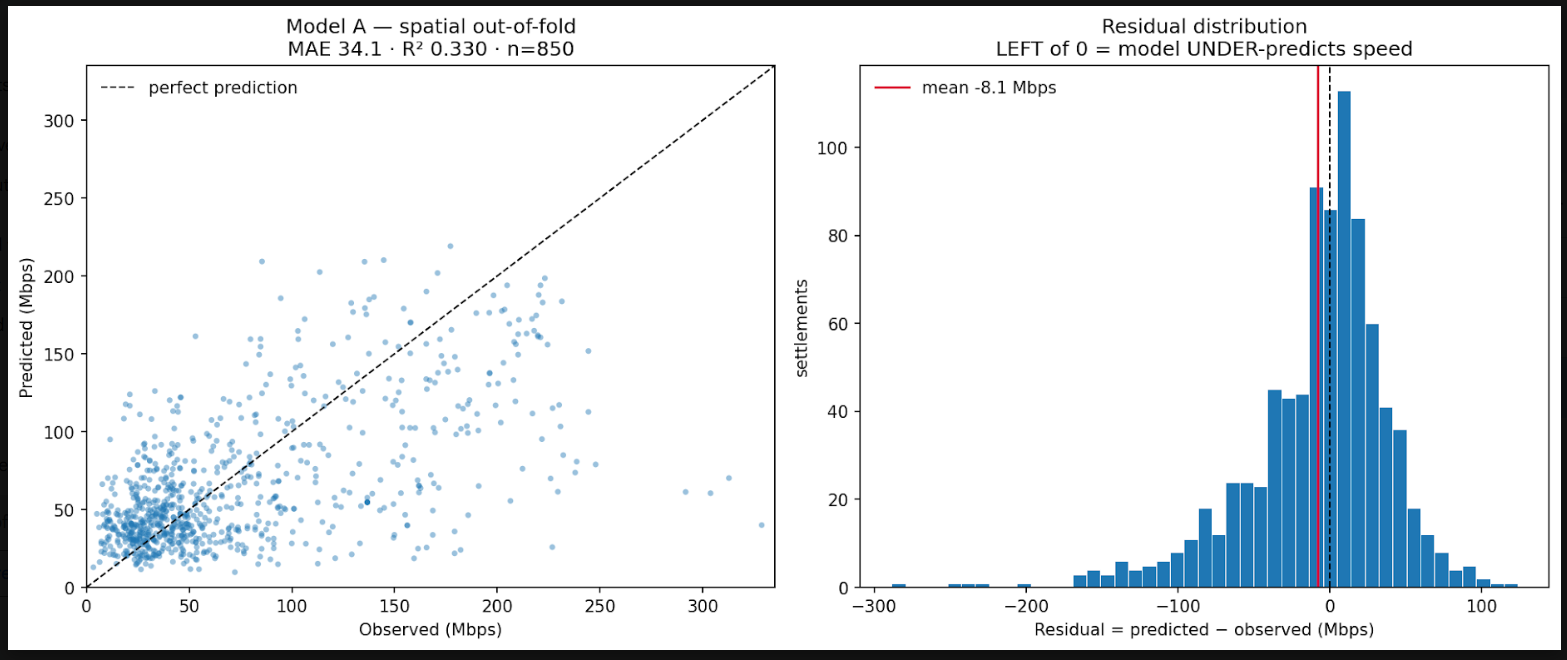

What to read from it: points track the diagonal at the low end and flatten above roughly
150 Mbps. The model identifies slow places reasonably and cannot identify fast ones, which
is the useful half for this project, and a limitation worth stating out loud.

### What this shows

**Left — predicted vs observed.** Each dot is one settlement, plotted against the dashed line
of perfect prediction. The cloud tracks the line up to roughly 75 Mbps, then flattens: above
150 Mbps observed, predictions sit between 50 and 200 and rarely reach the true value. This
is **regression to the mean**, and it is expected — the model has no network-side features, so
it can recognise the *kind of place* that tends to be slow but has no way to identify the
handful that are exceptionally fast. For a tool that exists to find underserved communities,
the accurate half is the useful half.

**Right — residual distribution.** Sharply peaked at zero, so the typical settlement is
predicted close to correctly. But the distribution is asymmetric: a long tail runs left to
−300 Mbps with no matching tail on the right. Those are the fast settlements from the left
panel, predicted far too low.

**Why mean and median disagree.** The mean residual is **−8.1 Mbps** while the median is
**+0.60**. That gap is the whole story: half the settlements are essentially unbiased, and the
negative mean is dragged entirely by the left tail. Reporting the mean alone would suggest a
systematic downward bias that most settlements do not have.

**Honest reading:** the model is reliable in the low-to-mid range where the decisions are
made, and unreliable above ~150 Mbps where they are not.

In [ ]:
# ══════════════════════════════════════════════════════════════════════
# GEOGRAPHIC ERROR MAP — where the model is wrong, and who it disadvantages.
# RdBu colormap: RED = low = negative = under-predicts speed
#                BLUE = high = positive = over-predicts speed
# ══════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(1, 2, figsize=(14, 6.5))
v = np.percentile(np.abs(tr.resid), 95)

sc = ax[0].scatter(tr.lon, tr.lat, c=tr.resid, cmap="RdBu", vmin=-v, vmax=v,
                   s=22, edgecolor="k", linewidth=.2)
plt.colorbar(sc, ax=ax[0], label="residual = predicted − observed (Mbps)")
ax[0].set(xlabel="lon", ylabel="lat",
          title="Per-settlement error\nRED = under-predicted speed · BLUE = over-predicted")
ax[0].set_aspect("equal")

bd = (tr.groupby("district", observed=True)
        .agg(mean_resid=("resid","mean"), n=("resid","size"),
             lon=("lon","mean"), lat=("lat","mean")).reset_index())
bd = bd[bd.n >= 10]
sc2 = ax[1].scatter(bd.lon, bd.lat, c=bd.mean_resid, cmap="RdBu", vmin=-v, vmax=v,
                    s=bd.n*6, edgecolor="k", linewidth=.6)
for _, r in bd.iterrows():
    ax[1].annotate(f"{r.district}\n{r.mean_resid:+.0f}", (r.lon, r.lat),
                   fontsize=7, ha="center", va="center")
plt.colorbar(sc2, ax=ax[1], label="mean residual (Mbps)")
ax[1].set(xlabel="lon", title="District mean error (n≥10) · size = training rows\nBLUE = looks better served than it is")
ax[1].set_aspect("equal")

plt.tight_layout()
plt.savefig(D + "outputs/plots/error_map.png", dpi=150, bbox_inches="tight")
plt.show()
print("Errors cluster spatially rather than scattering — which is itself the")
print("evidence that grouped cross-validation was necessary.")

Errors cluster spatially rather than scattering — which is itself the
evidence that grouped cross-validation was necessary.


### 📸 Error map

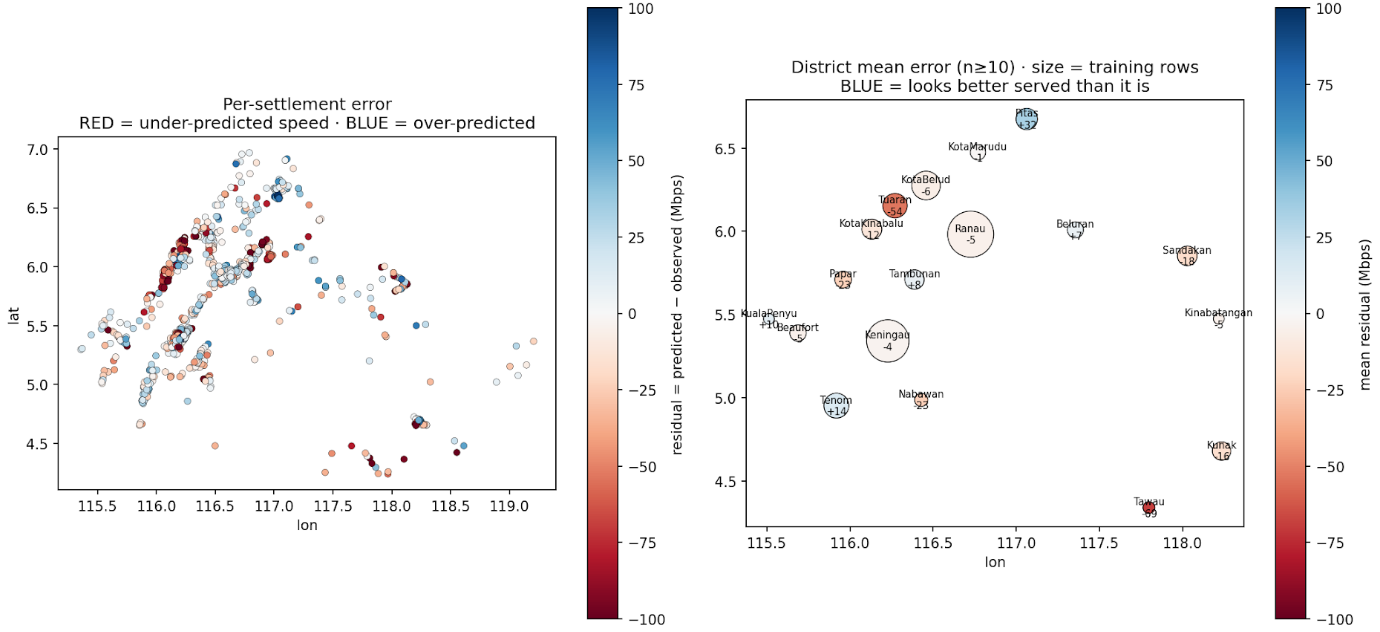

### What this shows

**Left — every settlement, coloured by error.** The critical observation is that errors
**cluster spatially** rather than scattering at random. Deep-red pockets sit along the west
coast around 116°E, and blue clusters appear in the northern interior. That clustering is the
direct evidence that grouped cross-validation was necessary: a random train/test split would
have put neighbouring settlements from the same red pocket on both sides of the line, and the
model would have been scored on geography it had effectively already seen.

**Right — district averages.** Circle size is the number of training settlements, so the large
faint circles (Ranau, Keningau) are well-measured districts where the model performs
acceptably. The small saturated ones are where it does not.

**The finding that matters — Pitas, +32 Mbps.** Pitas is the only strongly blue district, which
means the model **over-predicts** its speed: it looks better served than it measures. Because
DIPI ranks slower places higher, an inflated speed estimate would push Pitas settlements
*down* the priority list. Pitas is a poor, rural, northern district — exactly the kind of
community this project exists to surface. This is the harm the fairness audit was built to
catch.

**The opposite pattern — Tawau (−69), Tuaran (−54).** Here the model under-predicts, so those
districts would be over-prioritised relative to their measured performance.

**Why it happens.** With districts held out and no location features permitted, the model has
no way to learn regional level. It regresses toward a Sabah-wide average, pulling genuinely
fast districts down and genuinely slow ones up.

**What we did about it.** Adding a regional feature (`division`) was tested as a remedy and
made overall accuracy worse without fixing the bias. Rather than hide it, the bias is
published in the model card and it **constrains use**: the predictions are valid for survey
targeting, and are never permitted as an input to the DIPI ranking.

In [ ]:
# ══════════════════════════════════════════════════════════════════════
# SHAP BEESWARM — global explainability for the selected model.
# Axis is log1p space. Do NOT relabel it Mbps.
# ══════════════════════════════════════════════════════════════════════
plt.figure()
shap.summary_plot(sv, X_pred, show=False, max_display=len(SEL_FEATURES))
plt.title("SHAP — impact on log1p(dl_mbps), NOT Mbps\nfactors associated with the modelled estimate", fontsize=10)
plt.xlabel("SHAP value (log1p Mbps units)")
plt.tight_layout()
plt.savefig(D + "outputs/plots/shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"model base value: {np.expm1(expl.expected_value):.1f} Mbps")
print("A SHAP value of +0.25 in log space is roughly a x1.28 multiplier, so its")
print("effect in Mbps depends on the settlement — it is NOT additive in Mbps.")
print("\nWording rule: 'factors associated with this estimate', never 'causes'.")

model base value: 52.6 Mbps
A SHAP value of +0.25 in log space is roughly a x1.28 multiplier, so its
effect in Mbps depends on the settlement — it is NOT additive in Mbps.

Wording rule: 'factors associated with this estimate', never 'causes'.


### 📸 SHAP beeswarm
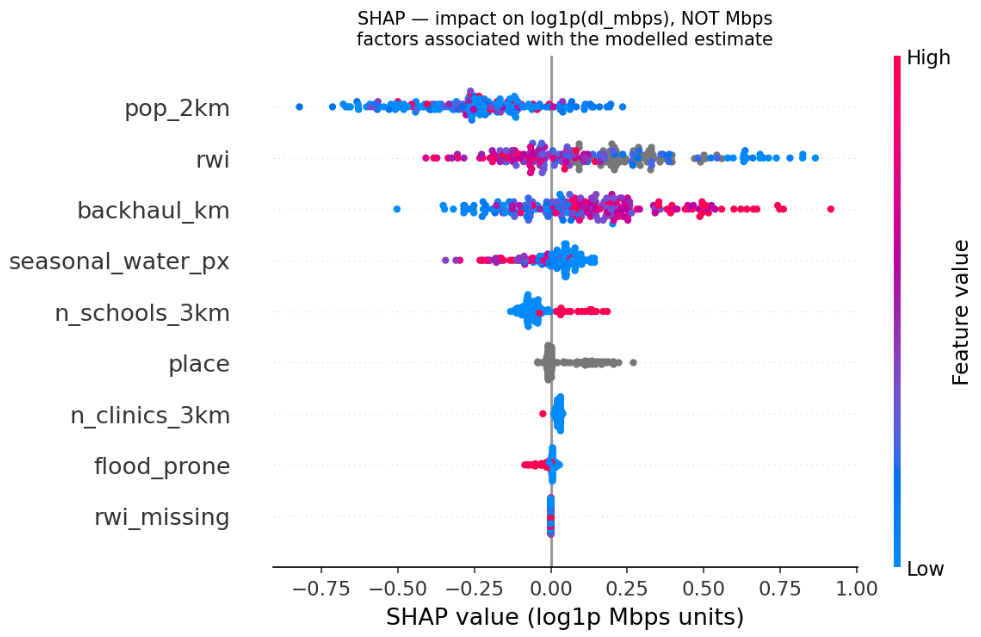

---

### What this shows

Each dot is one of the 216 predicted settlements. Position on the x-axis is how much that
feature pushed *that settlement's* estimate up or down. Colour is the feature's value — pink
for high, blue for low, grey where the value is missing or categorical.

**Three features carry the model.** `pop_2km`, `rwi` and `backhaul_km` have visibly wider
spreads than everything below them; the remaining six sit close to zero and contribute little.

**`backhaul_km` is the cleanest signal.** Pink dots (far from town) sit firmly on the right,
blue dots (close to town) on the left — remoteness pushes the estimate down in a consistent,
interpretable way.

**`pop_2km` is the strongest but the least tidy.** Blue points (few people) spread far to the
left, so low population drives estimates down hard. But the pink points are not cleanly on the
right, which means population interacts with other features rather than acting on its own.
Worth stating plainly rather than over-explaining.

**The grey dots on `rwi` are the 96 settlements with no wealth data.** They sit mid-range
rather than at either extreme — visible confirmation that missing wealth is treated as
*unknown*, not as *poor*.

**`rwi_missing` contributes nothing.** We added it in case missingness itself signalled
remoteness. It didn't. We tested it and report that it added nothing.

### ⚠️ Two things to read carefully

**The axis is `log1p(dl_mbps)`, not Mbps.** A SHAP value of +0.25 is roughly a **×1.28
multiplier** on that settlement's estimate, not "+0.25 Mbps". Effects combine
multiplicatively, so the same value means a larger Mbps swing for a fast settlement than a
slow one.

**These are associations, not causes.** The correct phrasing is *"factors associated with this
estimate"*. Nothing here says that population *causes* connectivity — only that the model
found the two move together across the 850 settlements it learned from.

### What it confirms about the model's limits

Every feature on this chart is demographic, economic or geographic. **Not one describes the
network.** The model is recognising *the kind of place that tends to be slow*, not measuring
coverage — which is precisely the limitation documented in the model card.

## Notebook 2 complete

### Outputs in `MyDrive/Dataset/outputs/`

| File | Contents |
|---|---|
| `model_predictions_v1.csv` | **the deliverable** — 1,448 rows, estimates, disagreement, top-3 factors |
| `model_report.json` | validation numbers in the dashboard's field names |
| `metrics.json` | full model card: ablations, bias table, limitations |
| `run_config.json` | the frozen contract — target, rules, features, seed, versions |
| `fold_assignment.csv` | the frozen spatial folds |
| `models/` | 5 fold models + full-fit model + manifest |
| `plots/` | three diagnostic figures |
| `features_with_ocid.parquet` | features including the rejected OpenCelliD group |

### What the model may and may not be used for

**May:** estimate likely speed for unmeasured settlements, with disagreement shown; rank
where a new measurement would be most valuable.

**May not:** feed the DIPI ranking, stand in for a measurement, or be described as coverage.

### Honest summary

Five model variants were tested on identical folds, seeds and parameters. **One was selected
and four were rejected**, each with a recorded reason. The gap between the naive and spatial
cross-validation scores is reported rather than hidden, and the per-district bias is published
alongside the headline metric.

A trustworthy score on unseen geography is worth more than an inflated one from a random split.

### After this notebook:
Run [`tower_scenarios.py`](https://github.com/RextonRZ/dino-slayer/blob/main/dataset/tower_scenarios.py)
→ `tower_pairs.csv`, the 10,070 candidate mast-to-village paths that §4 screens.